"""DON_map_spare_u_to_solution_react_diffusion

# Reaction Diffusion Equation 
## Maping sparse u data to the solution space

$$ \frac{du}{dt} = D \frac{d^2u}{dx^2} + K u^2 + f(x) ~\forall ~x,t \in [0,1]$$

$$ IC: u(x,0) = 0 ~ \forall ~ x \in [0,1],$$

$$ BC: u(0,t) = u(1,t) = 0 ~ \forall ~t \in [0,1] $$
"""

In [1]:
from flax import linen as nn
from typing import Sequence, Tuple
import jax
import jax.numpy as jnp
from torch.utils import data
from functools import partial
import time
import optax
import scipy.io
import os
import argparse
import matplotlib.pyplot as plt
import shutil
import orbax.checkpoint as ocp
import pandas as pd
from jax import jvp
import pickle
from sklearn import metrics
from termcolor import colored
import random
import numpy as np

In [2]:
## All inputs

path_D_test = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/D_coeff_test.npy'
path_D_train = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/D_coeff_train.npy'
path_branch_test = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/branch_test.npy'
path_branch_train = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/branch_train.npy'
path_target_test = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/target_test.npy'
path_target_train = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/target_train.npy'
path_trunk_test = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/trunk_test.npy'
path_trunk_train = '/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Reaction_Diffusion/trunk_train.npy'


n_train = 8500
p_data_train = 200
p_res_train = 2500
batch_size = 75
n_test = 101
n_sensors = p_data_train #101*101
branch_layers = [64, 64, 64]
branch_nu_layers = [64, 64, 64]
branch_input_features = 1
trunk_layers = [64, 64, 64]
trunk_input_features = 2
hidden_dim = 100
hidden_dim_nu = 1
p_test = 101
result_dir = './'
epochs = 80000
vis_iter = 1000
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

In [3]:

D_test = jnp.array(np.load(path_D_test))
D_train = jnp.array(np.load(path_D_train))
branch_test = jnp.array(np.load(path_branch_test))
branch_train = jnp.array(np.load(path_branch_train))
target_test = jnp.array(np.load(path_target_test))
target_train = jnp.array(np.load(path_target_train))
trunk_test = jnp.array(np.load(path_trunk_test))
trunk_train = jnp.array(np.load(path_trunk_train))

print("D_test: ", str(D_test.shape))   # (n_test, 1)
print("D_train: ", str(D_train.shape))  # (n_train, 1)
print("branch_test: ", str(branch_test.shape))  # (n_test, nx)
print("branch_train: ", str(branch_train.shape)) # (n_train, nx)
print("target_test: ", str(target_test.shape)) # (n_train, nt, nx)
print("target_train: ", str(target_train.shape)) # (n_train, nt*nx )
print("trunk_test: ", str(trunk_test.shape)) # (n_train, nt, nx)
print("trunk_train: ", str(trunk_train.shape)) # (n_train, nt*nx )

2025-11-27 02:37:20.362555: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.68. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


D_test:  (3600, 1)
D_train:  (14400, 1)
branch_test:  (3600, 101)
branch_train:  (14400, 101)
target_test:  (3600, 101, 101)
target_train:  (14400, 101, 101)
trunk_test:  (3600, 300, 2)
trunk_train:  (14400, 300, 2)


u_noise_1pct shape: (3600, 200)
(101, 101)
(101, 101)
(101, 101)


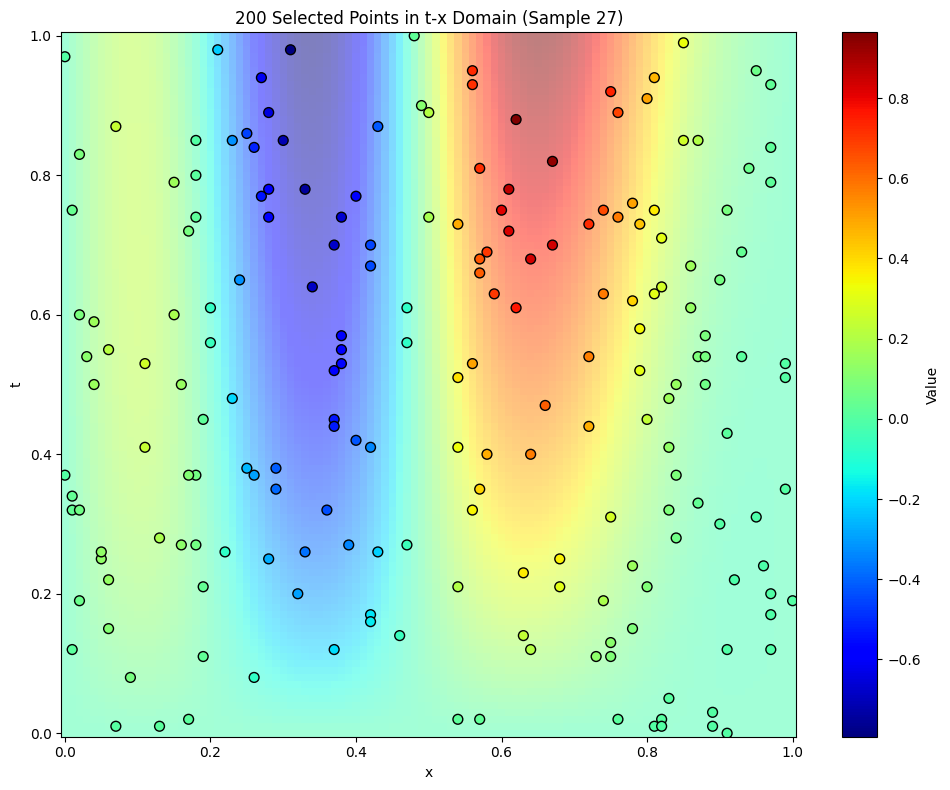

In [4]:
def extract_points(data, num_points=200):
    seed = 0
    key = jax.random.PRNGKey(seed)
    samples, ntt, nxx = data.shape
    flattened_data = data.reshape(samples, ntt * nxx)
#     selected_indices = np.random.choice(height * width, num_points, replace=False)
    random_indices = jax.random.choice(key, ntt* nxx, shape=(num_points,), replace=False)
#     extracted_data = flattened_data[:, selected_indices]
    t_indices = random_indices // ntt
    x_indices = random_indices % nxx
    t = t_indices / (ntt - 1)
    x = x_indices / (nxx - 1)

    # Create y array with (t, x) coordinates
    location = jnp.stack([t, x], axis=-1)

    # Create a grid representing the original domain
    tt = np.linspace(0, 1, 101)
    xx = np.linspace(0, 1, 101)
    XX, TT = jnp.meshgrid(xx, tt, indexing='ij')

    y_test = jnp.stack([TT.flatten(), XX.flatten()], axis=-1)

    # Sample s values from u_data
    # print(data.shape)
    data_reshape = data.reshape(data.shape[0], 101, 101)
    # print(data_reshape.shape)
    extracted_data = data_reshape[:,t_indices, x_indices]

    return extracted_data, location, y_test

# Extract 300 points from each sample
data_output, location, y_test = extract_points(target_test, p_data_train)

# noise 
def add_gaussian_noise(u_data, key, percentage):
    """
    u_data: (N_train, num_points)
    percentage: float (0.01, 0.03, 0.05)
    """
    # Compute scaling based on mean absolute value
    scale = percentage * jnp.mean(jnp.abs(u_data))

    # Sample Gaussian noise
    noise = scale * jax.random.normal(key, shape=u_data.shape)

    # Add noise
    return u_data + noise


key = jax.random.PRNGKey(42)

u_noise_1pct = add_gaussian_noise(data_output, key, 0.00)

print("u_noise_1pct shape:", u_noise_1pct.shape)

data_output = u_noise_1pct

# Choose a sample to plot (e.g., the first sample)
sample_index = 27

# Create the plot
plt.figure(figsize=(10, 8))

# Create a grid representing the original domain
t = np.linspace(0, 1, 101)  # Assuming t goes from 0 to 1
x = np.linspace(0, 1, 101)  # Assuming x goes from 0 to 1
X, T = jnp.meshgrid(x, t, indexing='ij')

print(target_test[sample_index].shape)
u_test = target_test[sample_index,:]
print(u_test.shape)
u_test = u_test.reshape(101, 101)
print(u_test.shape)
# Plot the full domain as a light background
plt.pcolormesh(X, T, u_test.T, cmap='jet', alpha=0.5)

selected_values = data_output[sample_index]

# Plot the selected points
scatter = plt.scatter(location[:,1], location[:,0], c=selected_values, cmap='jet', s=50, edgecolor='black')

plt.colorbar(scatter, label='Value')
plt.title(f'{p_data_train} Selected Points in t-x Domain (Sample {sample_index})')
plt.xlabel('x')
plt.ylabel('t')

plt.tight_layout()
plt.show()


/tmp/ipykernel_51576/1324393057.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)


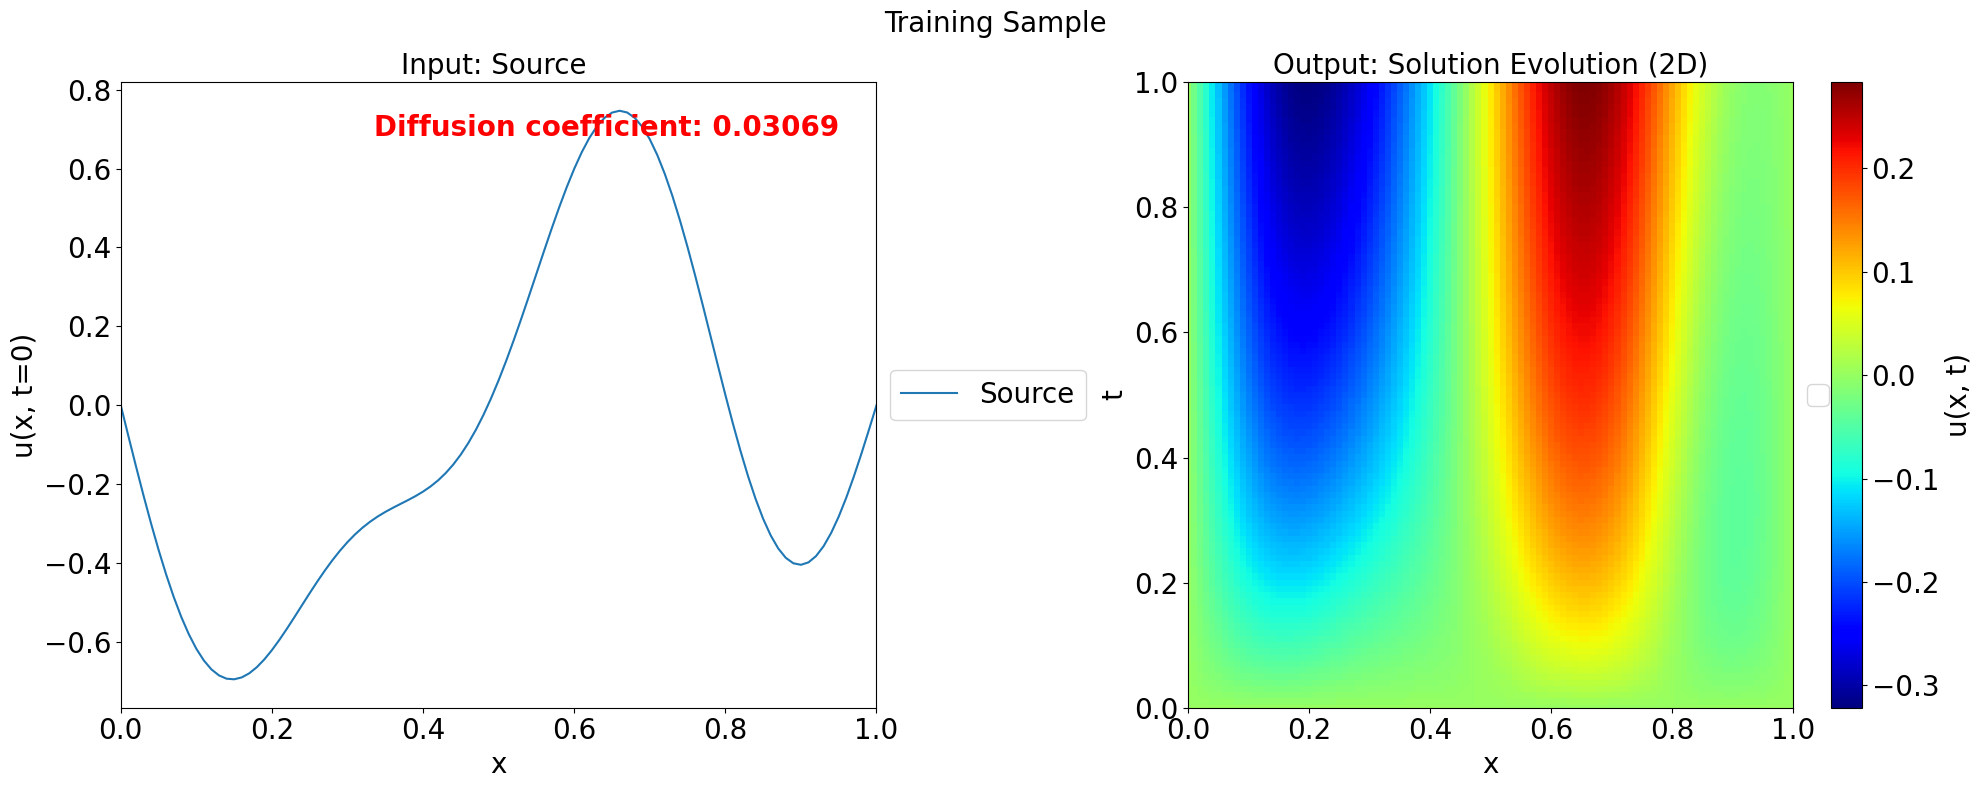

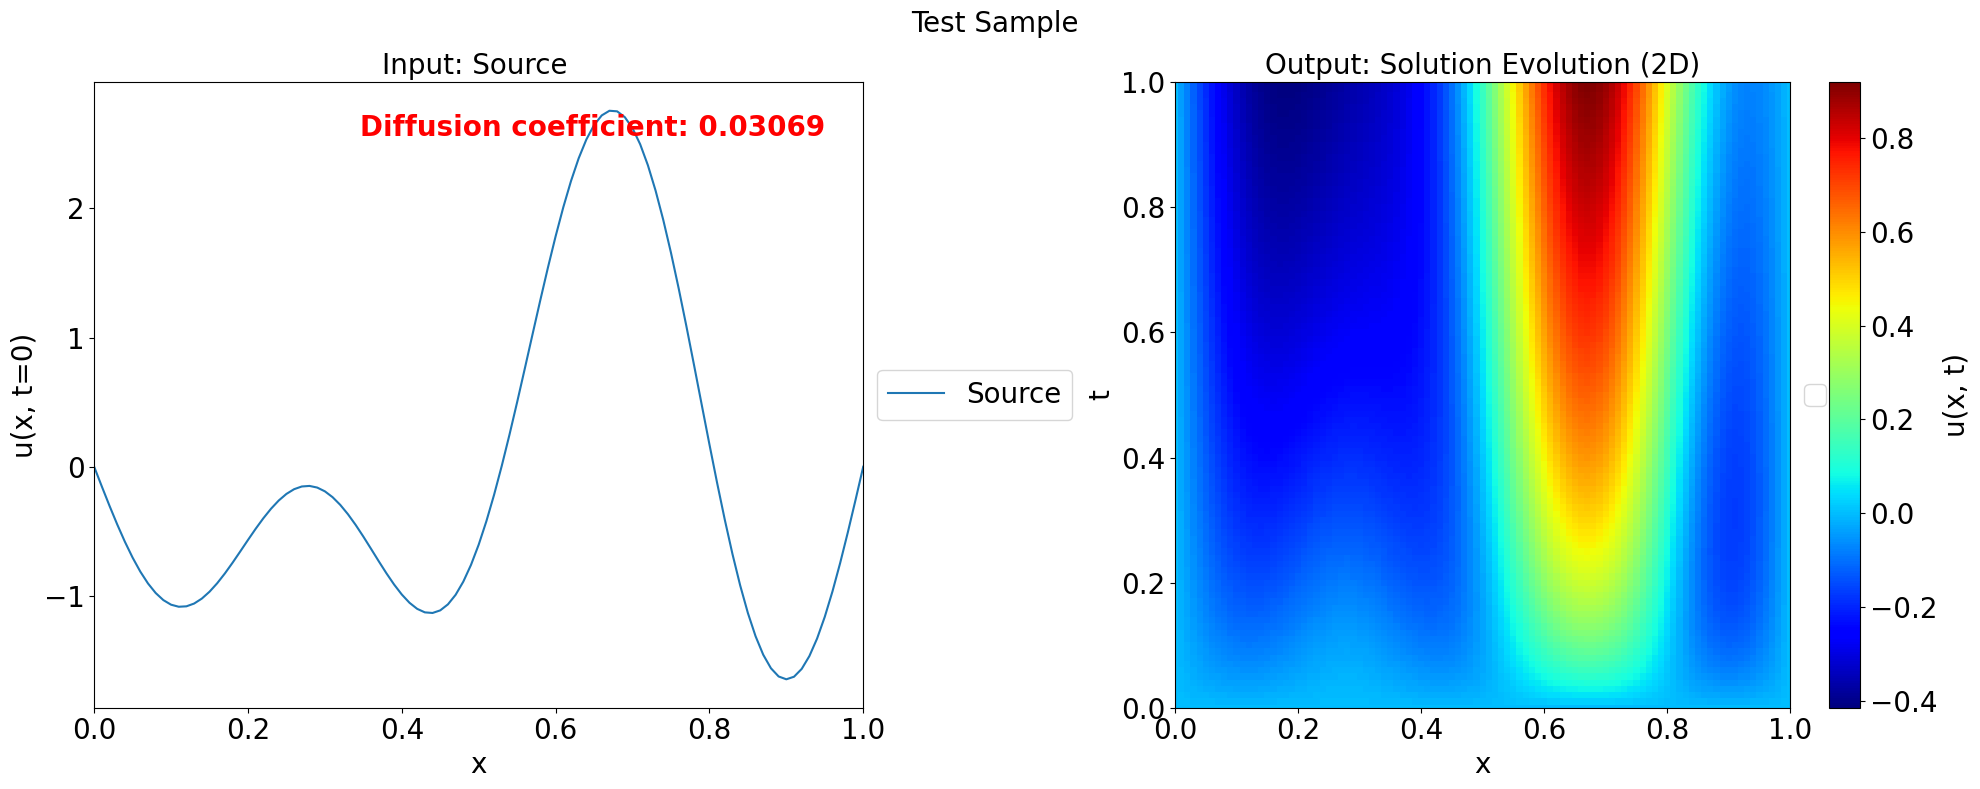

In [5]:
def plot_sample(D, f_sol, u_sol, sample_index, title):
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(title, fontsize = 20)

    # Create x and t arrays for the physical domain
    x = np.linspace(0, 1, f_sol.shape[1])
    t = np.linspace(0, 1, f_sol.shape[1])

    XX, TT = jnp.meshgrid(x, t, indexing='ij')

    # Plot input
    ax1.plot(x, f_sol[sample_index, :], label='Source')
    ax1.set_title('Input: Source ', fontsize = 20)
    ax1.set_xlabel('x', fontsize = 20)
    ax1.set_ylabel('u(x, t=0)', fontsize = 20)
    ax1.set_xlim(0, 1)
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax1.tick_params(axis='both', which='major', labelsize = 20)
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

    # Display viscosity as text
    viscosity = D[sample_index]
    ax1.text(0.95, 0.95, f'Diffusion coefficient: {viscosity[0]:.5f}',
             verticalalignment='top', horizontalalignment='right',
             transform=ax1.transAxes, color='red', fontweight='bold', fontsize = 20)

    # Plot output as pcolor (flipped)
    im = ax3.pcolormesh(XX, TT, u_sol[sample_index, :, :].T, cmap='jet', shading='auto')
    ax3.set_title('Output: Solution Evolution (2D)', fontsize = 20)
    ax3.set_xlabel('x', fontsize = 20)
    ax3.set_ylabel('t', fontsize = 20)
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    ax3.tick_params(axis='both', which='major', labelsize = 20)
    ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)

    cbar = fig.colorbar(im, ax=ax3)
    cbar.set_label('u(x, t)', fontsize=20)
    cbar.ax.tick_params(labelsize=20)

    plt.tight_layout()
    plt.show()

# Plot a sample from the training set
train_sample_index = 201  # You can change this to view different samples
plot_sample(D_train, branch_train, target_train, train_sample_index, "Training Sample")

# Plot a sample from the test set
test_sample_index = 4  # You can change this to view different samples
plot_sample(D_test, branch_test, target_test, test_sample_index, "Test Sample")

# Optional: Save the figures
# plt.savefig('burgers_equation_visualization_with_physical_domain.png', dpi=300, bbox_inches='tight')

In [6]:
class DataGenerator(data.Dataset):
    def __init__(self, u, y, s, D, fx, batch_size, gen_key):
        self.u = u
        self.y = y
        self.s = s
        self.D = D
        self.fx = fx
        self.N = D.shape[0]
        self.batch_size = batch_size
        self.key = gen_key

    def __getitem__(self, index):
        """Generate one batch of data"""
        self.key, subkey = jax.random.split(self.key)
        inputs, outputs, D, fx = self.__data_generation(subkey)
        return inputs, outputs, D, fx

    @partial(jax.jit, static_argnums=(0,))
    def __data_generation(self, key_i):
        """Generates data containing batch_size samples"""
        idx = jax.random.choice(key_i, self.N, (self.batch_size,), replace=False)
        s = self.s[idx, :]
        y = self.y[:, :]
        u = self.u[idx, :]
        D = self.D[idx]
        fx = self.fx[idx]
        # Construct batch
        inputs = (u, y)
        outputs = s
        return inputs, outputs, D, fx

In [7]:
"""# Data generation for each samples"""

def generate_random_data_points(D_train_i, u_sol_train_i, key, num_points= 200):

    # Generate random indices for sampling points
    num_t, num_x = u_sol_train_i.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(num_points,), replace=False)

    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_x
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)

    y = jnp.stack([t, x], axis=-1)

    # Sample s values from u_data
    u = u_sol_train_i[t_indices, x_indices]

    # s = u_sol_train_i

    return u, y, u, D_train_i


def generate_one_res_training_data(D_train_i, u_sol_train_i, fx_i, key, num_points=200, p=2500):
    
    num_t, num_x = u_sol_train_i.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(num_points,), replace=False)

    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_t
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)

    # Create y array with (t, x) coordinates
    p_grid = int(jnp.sqrt(p))  # sqrt to get square grid

    t_res_i = jax.random.uniform(key, shape=(p_grid,), minval=0, maxval=1)
    t_res_i = jnp.sort(t_res_i)  # Sort to maintain increasing order
    x_res_i = jax.random.uniform(key, shape=(p_grid,), minval=0, maxval=1)
    x_res_i = jnp.sort(x_res_i)  # Sort to maintain increasing order
    x_res, t_res = jnp.meshgrid(x_res_i, t_res_i, indexing='ij')

    y = jnp.stack([t_res.flatten(), x_res.flatten()], axis=-1)  # Shape: (p, 2)

    # Sample s values from u_data
    u = u_sol_train_i[t_indices, x_indices]

    s = u_sol_train_i

    # Create x points for original fx
    x_original = jnp.linspace(0, 1, fx_i.shape[0])

    # Linear interpolation using JAX operations
    def interpolate(x_target):
        # Find indices of the two nearest points
        idx = jnp.searchsorted(x_original, x_target)
        idx = jnp.clip(idx, 1, len(x_original)-1)

        # Get the two nearest x points
        x0 = x_original[idx-1]
        x1 = x_original[idx]

        # Get the two nearest y points
        y0 = fx_i[idx-1]
        y1 = fx_i[idx]

        # Linear interpolation
        slope = (y1 - y0) / (x1 - x0)
        return y0 + slope * (x_target - x0)

    # Vectorize the interpolation function
    v_interpolate = jax.vmap(interpolate)

    # Interpolate fx at the random x points
    fx = v_interpolate(y[:, 1])  # Shape will be (p,)

    return u, y, s, D_train_i, fx


In [8]:
# Create test data
seed = 0
key = jax.random.PRNGKey(seed)
keys = jax.random.split(key, 6)

# known u data
u_data_train, y_data_train, s_data_train, D_data_train = (jax.vmap(generate_random_data_points,
                                                     in_axes=(0, 0, None, None))
                                            (D_train, target_train, key, p_data_train))

u_noise_1pct = add_gaussian_noise(u_data_train, keys[0], 0.0)

print("u_noise_1pct shape:", u_noise_1pct.shape)

u_data_train = u_noise_1pct

print("u_data_train: ", str(u_data_train.shape))  # Expected: (N_train, 300)
print("s_data_train: ", str(s_data_train.shape))  # Expected: (N_train, 101, 101)
print("y_data_train: ", str(y_data_train.shape))  # Expected: (N_train, 300, 2)
print("D_data_train: ", str(D_data_train.shape))  # Expected: (N_train,)

# Residual data
# key_res = jax.random.split(keys[0], n_train)
u_res_train, y_res_train, s_res_train, D_res_train, f_res_train = (jax.vmap(generate_one_res_training_data,
                                                 in_axes=(0, 0, 0, None, None, None))
                                         (D_train, target_train, branch_train, key, p_data_train, p_res_train))

u_noise_1pct = add_gaussian_noise(u_res_train, keys[0], 0.0)

print("u_noise_1pct shape:", u_noise_1pct.shape)

u_res_train = u_noise_1pct


print("u_res_train: ", str(u_res_train.shape)) # Expected: (N_train, 300)
print("s_res_train: ", str(s_res_train.shape))  # Expected: (N_train, 101, 101)
print("y_res_train: ", str(y_res_train.shape)) # Expected: (N_train, 2500, 2)
print("D_res_train: ", str(D_res_train.shape)) # Expected: (N_train, )
print("f_res_train: ", str(f_res_train.shape)) # Expected: (N_train, )


u_noise_1pct shape: (14400, 200)
u_data_train:  (14400, 200)
s_data_train:  (14400, 200)
y_data_train:  (14400, 200, 2)
D_data_train:  (14400, 1)
u_noise_1pct shape: (14400, 200)
u_res_train:  (14400, 200)
s_res_train:  (14400, 101, 101)
y_res_train:  (14400, 2500, 2)
D_res_train:  (14400, 1)
f_res_train:  (14400, 2500)



Statistics for sample 20:

Original f:
Min value: -1.7168
Max value: 1.8130
Mean value: -0.2479
Number of points: 101

Interpolated f:
Min value: -1.7140
Max value: 1.7923
Mean value: -0.2247
Number of points: 2500


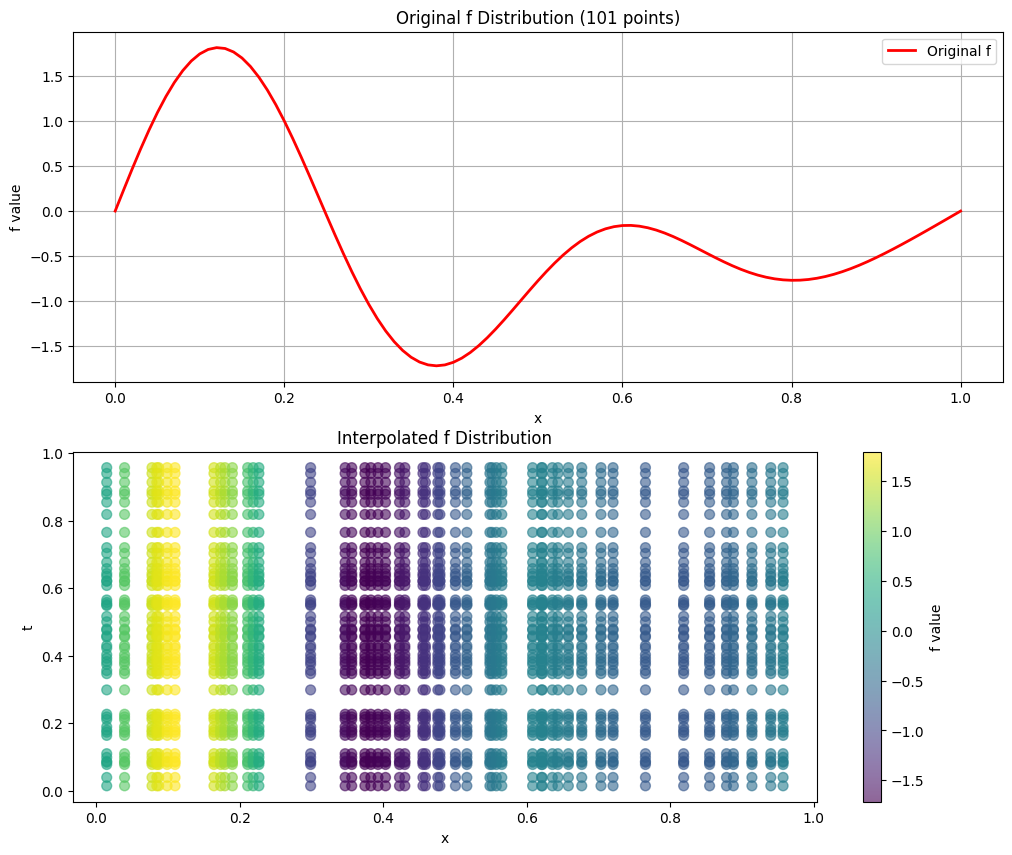

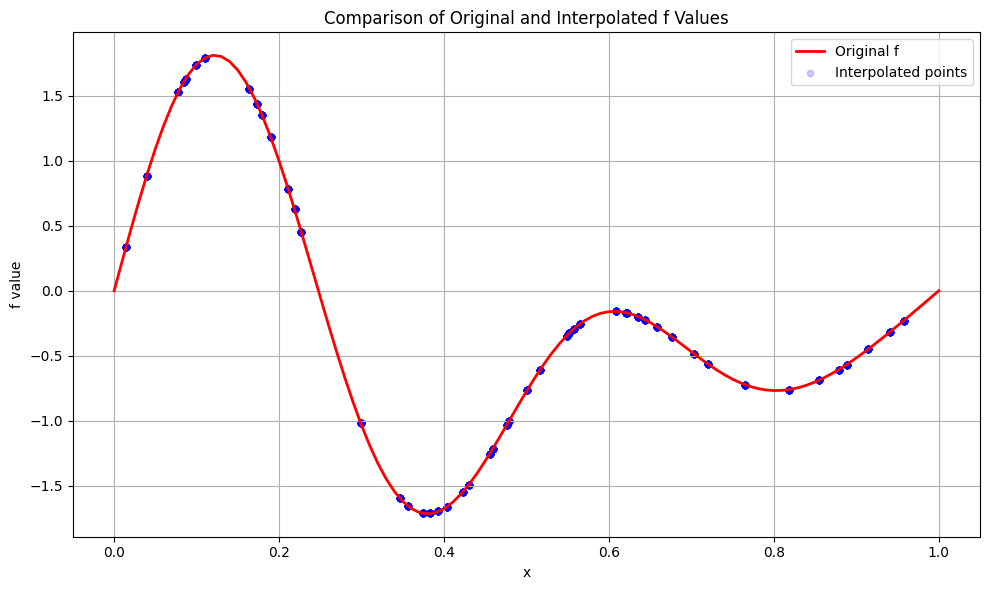

In [9]:
# Select one sample
sample_idx = 20
f_interpolated = f_res_train[sample_idx]
y_sample = y_res_train[sample_idx]
f_original = branch_train[sample_idx]  # Original f of size 101

# Create x points for original data
x_original = np.linspace(0, 1, 101)  # Since original f is size 101

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Original f
ax1.plot(x_original, f_original, 'r-', label='Original f', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('f value')
ax1.set_title('Original f Distribution (101 points)')
ax1.grid(True)
ax1.legend()

# Plot 2: Scatter plot of interpolated values
scatter = ax2.scatter(y_sample[:, 1], y_sample[:, 0], c=f_interpolated,
                     cmap='viridis', s=50, alpha=0.6)
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('Interpolated f Distribution')
plt.colorbar(scatter, ax=ax2, label='f value')

# Add an extra comparison plot
plt.figure(figsize=(10, 6))
plt.plot(x_original, f_original, 'r-', label='Original f', linewidth=2)
plt.scatter(y_sample[:, 1], f_interpolated, c='blue', s=20, alpha=0.2, label='Interpolated points')
plt.xlabel('x')
plt.ylabel('f value')
plt.title('Comparison of Original and Interpolated f Values')
plt.grid(True)
plt.legend()

# Print some statistics
print(f"\nStatistics for sample {sample_idx}:")
print("\nOriginal f:")
print(f"Min value: {np.min(f_original):.4f}")
print(f"Max value: {np.max(f_original):.4f}")
print(f"Mean value: {np.mean(f_original):.4f}")
print(f"Number of points: {len(f_original)}")

print("\nInterpolated f:")
print(f"Min value: {np.min(f_interpolated):.4f}")
print(f"Max value: {np.max(f_interpolated):.4f}")
print(f"Mean value: {np.mean(f_interpolated):.4f}")
print(f"Number of points: {len(f_interpolated)}")

plt.tight_layout()
plt.show()


In [10]:
# Create data generators
data_dataset = DataGenerator(u_data_train, y_data_train, s_data_train, D_data_train, branch_train, batch_size, keys[3])
res_dataset = DataGenerator(u_res_train, y_res_train, s_res_train, D_res_train, f_res_train, batch_size, keys[2])


In [11]:
# DeepONet class

class DeepONet(nn.Module):
    branch_layers: Sequence[int]
    trunk_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, branch_x, trunk_x):

        init = nn.initializers.glorot_normal()

        if branch_x.ndim == 1:
            branch_x = jnp.expand_dims(branch_x, axis=-1)

#         print("branch_x_in: ", str(branch_x.shape))
        # Branch network [batch_size, 1]
        for i, fs in enumerate(self.branch_layers[:-1]):
            branch_x = nn.Dense(fs, kernel_init=init, name=f"branch_{i}")(branch_x)
            branch_x = nn.activation.tanh(branch_x)
        branch_x = nn.Dense(self.branch_layers[-1], name=f"branch_{i+1}", kernel_init=init)(branch_x)
        #[batch_size, p]
#         print("branch_x_out: ", str(branch_x.shape))

        # Trunk network
        # [x_num, 2]
        # Ensure trunk_x has at least 2 dimensions
        if trunk_x.ndim == 1:
            trunk_x = jnp.expand_dims(trunk_x, axis=0)

#         print("trunk_x_in: ", str(trunk_x.shape))

        for i, fs in enumerate(self.trunk_layers):
            trunk_x = nn.Dense(fs, kernel_init=init, name=f"trunk_{i}")(trunk_x)
            trunk_x = nn.activation.tanh(trunk_x)

#         print("trunk_x_out: ", str(trunk_x.shape))

         # [x_num, p]

        # Compute the final output
        # Input shapes:
        # branch: [batch_size, p]
        # trunk: [x_num, p]
        # output: [batch_size, x_num]
        result = jnp.einsum('ij,kj->ik', branch_x, trunk_x)

        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        result += bias

        return result

In [12]:
"""# MLP for D"""

class MLP_D(nn.Module):
    h_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, x, training=False):
        init = nn.initializers.glorot_normal()
        # print(finput shape: {x.shape}")  # Debugging line
        for i, features in enumerate(self.h_layers):
            x = nn.Dense(features, kernel_init=init)(x)
            x = nn.silu(x)
        
        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        x += bias
        return x

In [13]:
@partial(jax.jit)
def mse(y_true, y_pred):
    return jnp.mean(jnp.square(y_true - y_pred))

@partial(jax.jit)
def mse_single(y_pred):
    return jnp.mean(jnp.square(y_pred))

@partial(jax.jit, static_argnums=(0,))
def apply_net(model_fn, params, branch_input, *trunk_in):
    # Define forward pass for normal DeepOnet that takes series of trunk inputs and stacks them
    if len(trunk_in) == 1:
        trunk_input = trunk_in[0]
    else:
        trunk_input = jnp.stack(trunk_in, axis=-1)
    out = model_fn(params, branch_input, trunk_input)

    # Reshape to vector for single output for easier gradient computation
    # TODO: Adapt / Check squeeze
    if out.shape[1]==1:
        out = jnp.squeeze(out, axis=1)
    return out

@partial(jax.jit, static_argnums=(0,))
def apply_net_nu(model_fn_nu, params_nu, branch_input_data):
    out = model_fn_nu(params_nu, branch_input_data)

    # TODO: Adapt / Check squeeze
    if out.shape[0]==1:
        out = jnp.squeeze(out, axis=0)
    return out


@partial(jax.jit, static_argnums=(0, 1, 2, 3))
def step(optimizer, loss_fn, model_fn_nu, model_fn, opt_state, params_step, res_batch, data_batch):
    loss, gradient = jax.value_and_grad(loss_fn, argnums=2)(model_fn_nu, model_fn, params_step, res_batch, data_batch)
    updates, opt_state = optimizer.update(gradient, opt_state)
    params_step = optax.apply_updates(params_step, updates)

    return loss, params_step, opt_state

In [14]:
# Initialize model and params
# make sure trunk_layers and branch_layers are lists
trunk_layers = [trunk_layers] if isinstance(trunk_layers, int) else trunk_layers

branch_layers = [branch_layers] if isinstance(branch_layers, int) else branch_layers

# add output features to trunk and branch layers
trunk_layers = trunk_layers + [hidden_dim]
branch_layers = branch_layers + [hidden_dim]

# Convert list to tuples
trunk_layers = tuple(trunk_layers)
branch_layers = tuple(branch_layers)

num_outputs = 1
model = DeepONet(branch_layers, trunk_layers, num_outputs)

# model function
model_fn = jax.jit(model.apply)

In [15]:
"""# model save function"""

def save_model_params(params, result_dir, filename='model_params.pkl'):
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)

    save_path = os.path.join(result_dir, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

def load_model_params(result_dir):
    load_path = os.path.join(result_dir)
    with open(load_path, 'rb') as f:
        params = pickle.load(f)
    return params

save = True
params_loaded = load_model_params('/home/droysar1/scr4_sgoswam4/Dibakar/INV_DON/RD/results_rd_d200_0/model_params_best.pkl')

print("Loaded best model parameters")

Loaded best model parameters


In [16]:
def loss_test_l2_error(model_fn, params, data_output, u_sol_test, return_data=False):

    def ff_net(t_test, x_test):
        s_pred = apply_net(model_fn, params, data_output, t, x)
        return s_pred

    # print(u_sol_test.shape)
    # s_pred = ff_net(t, x)
     # Generate random indices for sampling points
    _, num_t, num_x = u_sol_test.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(300,), replace=False)
    
    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_x
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)
    
    # Create y array with (t, x) coordinates
    y = jnp.stack([t, x], axis=-1)
    
    # Sample s values from u_data
    u = u_sol_test[:, t_indices, x_indices]

    s_pred = ff_net(t, x)
    # s_pred = s_pred.reshape(u_sol_test.shape[0], u_sol_test.shape[1], u_sol_test.shape[2])

    loss_test = mse(u, s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(jax.vmap(l2_norm_error)(u, s_pred))

    if return_data:
        return loss_test, l2_error, s_pred
    else:
        return loss_test, l2_error


Visualizing test sample at index 0


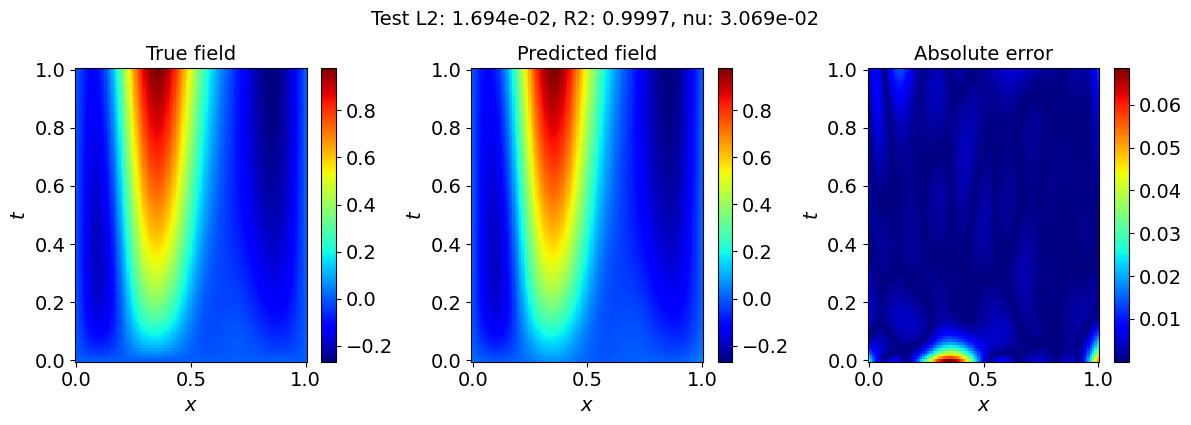

######################################################################################################################################################################################################################################
Visualizing test sample at index 1000


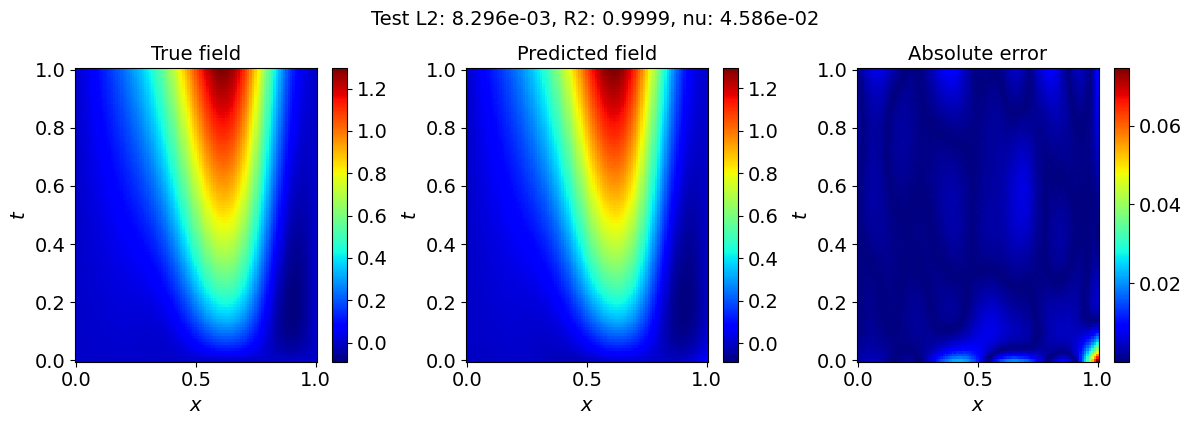

######################################################################################################################################################################################################################################
Visualizing test sample at index 2000


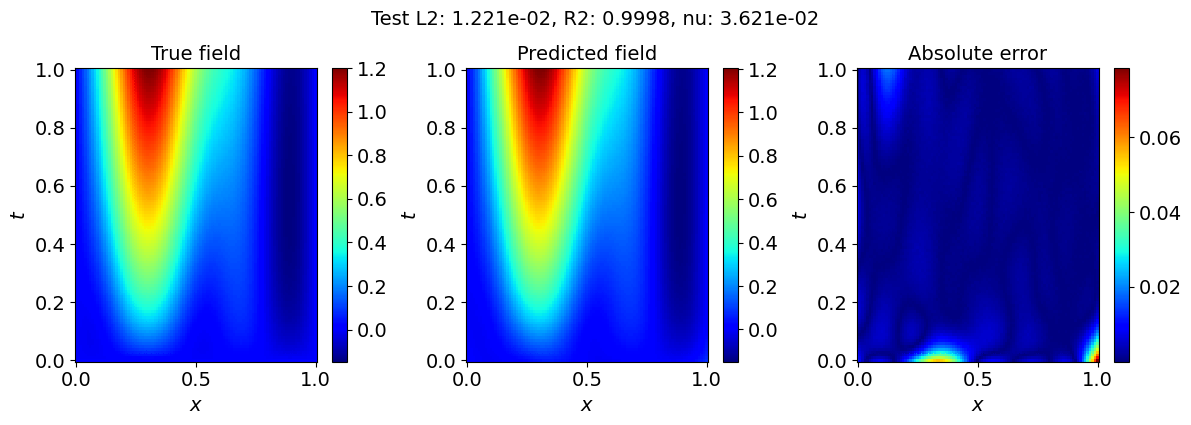

######################################################################################################################################################################################################################################
Visualizing test sample at index 3000


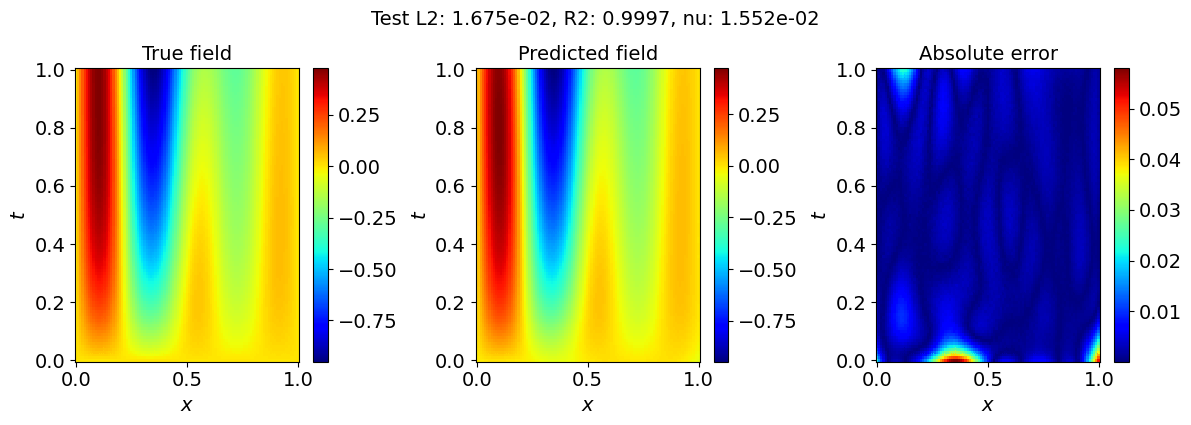

######################################################################################################################################################################################################################################
Mean MSE over test samples: 1.193e-05


In [17]:
def loss_test_l2_error_one_sample(model_fn, params, data_output, u_sol_test, idx, return_data=False):

    t_test = jnp.linspace(0, 1, u_sol_test.shape[1])
    x_test = jnp.linspace(0, 1, u_sol_test.shape[2])

    xx_test, tt_test = jnp.meshgrid(x_test, t_test, indexing='ij')

    y = jnp.stack([tt_test.flatten(), xx_test.flatten()], axis=-1) #(100*100, 2)

    t = y[:,0]
    x = y[:,1]

    data_output_i = data_output[idx, :]
    data_output_i = data_output_i[jnp.newaxis,:]

    def ff_net(t_test, x_test):
        s_pred = apply_net(model_fn, params, data_output_i, t, x)
        return s_pred

    s_pred = ff_net(t, x)
    s_pred = s_pred.reshape(u_sol_test.shape[1], u_sol_test.shape[2])
    s_pred = s_pred.T
    
    loss_test = mse(u_sol_test[idx, :, :], s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(l2_norm_error(u_sol_test[idx,:,:], s_pred))


    if return_data:
        return loss_test, l2_error, s_pred, u_sol_test[idx,:,:]
    else:
        return loss_test, l2_error

def visualize_show(model_fn, params, result_dir, epoch, data_output, u_sol_test, D_test, idx, test=False):
    # Generate data, and obtain error
    loss_test, l2_error, s_pred, s_test = loss_test_l2_error_one_sample(model_fn, params, data_output, u_sol_test, idx, return_data=True)

    x = jnp.linspace(0, 1, s_pred.shape[1])
    t = jnp.linspace(0, 1, s_pred.shape[0])

    x_test, t_test = jnp.meshgrid(x, t, indexing='ij')


    # Calculate R² score
    r2_value = metrics.r2_score(s_test.flatten(), s_pred.flatten())
    r2_value = float('%.4f' % r2_value)

    # Plot
    fig = plt.figure(figsize=(12, 4))

    # Adjusting layout for more vertical space
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.7, wspace=0.4, hspace=0.1)

    # Plot Exact u over time using pcolor
    ax = fig.add_subplot(1, 3, 1)
    plt.pcolor(x_test, t_test, s_test.T, cmap='jet', shading='auto')
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$t$', fontsize=14)
    ax.set_title('True field', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()

    # Plot Predicted u over time using pcolor
    ax = fig.add_subplot(1, 3, 2)
    plt.pcolor(x_test, t_test, s_pred.T, cmap='jet', shading='auto')
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$t$', fontsize=14)
    ax.set_title('Predicted field', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()

    # Plot Absolute error using pcolor

    u_diff = s_test.T - s_pred.T

    ax = fig.add_subplot(1, 3, 3)
    plt.pcolor(x_test, t_test, jnp.abs(u_diff), cmap='jet', shading='auto')
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel(r'$x$', fontsize=14)
    ax.set_ylabel(r'$t$', fontsize=14)
    ax.set_title('Absolute error', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()


    if test:
        plt.suptitle(f'Test L2: {l2_error:.3e}, R2: {r2_value}, nu: {D_test[idx][0]:.3e}', y=1.05, fontsize=14)
    else:
        plt.suptitle(f'Train L2: {l2_error:.3e}, R2: {r2_value:.3e}', y=1.05, fontsize=14)

    # Show or save the plot
#     if save:
#         plt.savefig(os.path.join(result_dir, f'Test_Sample_{idx}.pdf'))
    plt.show()
    plt.close()
    print(colored('#' * 230, 'green'))
    return r2_value  # Return R² score for each visualization

# Initialize an empty list to store MSE values
mse_values = []

# # Load the best model parameters
# best_params = load_model_params(result_dir, filename='model_params_best.pkl')
# print("Loaded best model parameters")


# Loop over every 20th index to visualize and calculate R²
for i in range(target_test.shape[0]):
    if i % 1000 == 0:
        idx = i
        print(f"Visualizing test sample at index {idx}")

        # Visualize and calculate R² score for every 20th index
        visualize_show(model_fn, params_loaded, result_dir, epochs, data_output, target_test, D_test, idx, True)

# Calculate loss and l2 error for test samples
loss_test, l2_error = loss_test_l2_error(model_fn, params_loaded, data_output, target_test, return_data=False)

# Calculate and print the mean MSE over all test samples
# mean_mse = jnp.mean(jnp.array(mse_values))
print(f"Mean MSE over test samples: {loss_test:.3e}")


In [18]:
# """# Loss function"""

# def loss_res_single_sample(model_fn_nu, model_fn, params_nu, params_loaded,
#                            u_data_single, t, x, fx_single, key):
#     """Compute residual + KL loss for one u_data sample."""
#     u_data_single = u_data_single[None, :]  # shape (1, latent_dim)

#     # Define PDE function
#     def f(t, x):
#         return apply_net(model_fn, params_loaded, u_data_single, t, x)

#     # Forward pass
#     s = f(t, x)

#     # Predict D (D) distribution parameters
#     D_pred_all = apply_net_nu(model_fn_nu, params_nu, u_data_single)
#     D_mean_raw, D_logstd_raw = D_pred_all[0], D_pred_all[1]

#     # Ensure ν_mean > 0
#     D_mean = jax.nn.softplus(D_mean_raw)

#     # Cap std to avoid explosion
#     D_std_raw = jnp.exp(D_logstd_raw)
#     D_std = jnp.minimum(D_std_raw, 0.2 * D_mean)

#     # Reparameterization trick
#     eps = jax.random.normal(key, shape=())
#     D_sampled = D_mean + eps * D_std

#     # Compute derivatives
#     _, s_x = jax.jvp(lambda x: f(t, x), (x,), (jnp.ones_like(x),))
#     _, s_t = jax.jvp(lambda t: f(t, x), (t,), (jnp.ones_like(t),))
#     _, s_xx = jax.jvp(lambda x: jax.jvp(lambda x: f(t, x), (x,), (jnp.ones_like(x),))[1],
#                       (x,), (jnp.ones_like(x),))

#     # PDE residual (Burgers-like form)
#     K = 0.01
#     pred = s_t - D_sampled * s_xx - K * s**2 - fx_single

#     # Residual loss
#     residual_loss = mse_single(pred)

#     # KL regularization
#     prior_mean, prior_std = 0.05, 0.01
#     kl_loss = 0.5 * (
#         (D_std / prior_std)**2 +
#         ((D_mean - prior_mean) / prior_std)**2 -
#         1 + 2 * jnp.log(prior_std) - 2 * jnp.log(D_std)
#     )

#     return residual_loss + 0.001 * kl_loss


# def loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch, key):
#     """Vectorized probabilistic residual loss (Burgers' PDE)."""
#     inputs, sol, D_ex, fx = res_batch
#     u_data, y_res = inputs

#     # Fixed t, x grid (same for all samples)
#     t = y_res[0, :, 0]
#     x = y_res[0, :, 1]

#     # Random keys for each sample
#     keys = jax.random.split(key, u_data.shape[0])

#     # Vectorized computation over (u_data[i], fx[i])
#     losses = jax.vmap(
#         lambda u, fxi, k: loss_res_single_sample(
#             model_fn_nu, model_fn, params_nu, params_loaded, u, t, x, fxi, k
#         )
#     )(u_data, fx, keys)

#     return jnp.mean(losses)


# def loss_data(model_fn, params, data_batch):

#     inputs, outputs, _,_ = data_batch
#     u_data, y = inputs

#     t = y[1, :, 0] # pick y for one sample (y is same for all samples)
#     x = y[1, :, 1]

#     s_pred = apply_net(model_fn, params, u_data, t, x)
#     s_pred = s_pred.reshape(outputs.shape[0], outputs.shape[1])

#     loss = mse(outputs, s_pred)
#     return loss

# def loss_fn(model_fn_nu, model_fn, params, res_batch, data_batch, key):
#     params_loaded, params_nu = params
#     loss_res_i = loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch, key)
#     loss_data_i = loss_data(model_fn, params_loaded, data_batch)
#     loss_value =  1 *loss_data_i + 1 * loss_res_i
#     return loss_value

"""# Loss function"""


def loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch):
    # Fetch data
    inputs, sol, D_ex, fx = res_batch
    u_data, y_res = inputs

    rand_num = random.randint(0, n_train)
    t = y_res[rand_num, :, 0]
    x = y_res[rand_num, :, 1]

    def f(t, x):
        return apply_net(model_fn, params_loaded, u_data, t, x)


    # Compute forward pass
    s = f(t, x)

    D_pred = apply_net_nu(model_fn_nu, params_nu, u_data)

    _, s_x = jax.jvp(lambda x: f(t, x), (x,), (jnp.ones_like(x),)) # changed f(t, x) to f(x, t)
    _, s_t = jax.jvp(lambda t: f(t, x), (t,), (jnp.ones_like(t),))


    _, s_xx = jax.jvp(lambda x: jax.jvp(lambda x: f(t, x), (x,), (jnp.ones_like(x),))[1], (x,), (jnp.ones_like(x),))


    D_pred = D_pred.reshape(-1,1)

    K = 0.01

    # Compute residual

    pred = s_t - D_pred * s_xx - K * s**2 - fx

    # Compute loss
    loss = mse_single(pred)
    return loss

def loss_data(model_fn, params, data_batch):

    inputs, outputs, _,_ = data_batch
    u_data, y = inputs

    t = y[1, :, 0] # pick y for one sample (y is same for all samples)
    x = y[1, :, 1]

    s_pred = apply_net(model_fn, params, u_data, t, x)
    s_pred = s_pred.reshape(outputs.shape[0], outputs.shape[1])

    loss = mse(outputs, s_pred)
    return loss

def loss_fn(model_fn_nu, model_fn, params, res_batch, data_batch):
    params_loaded, params_nu = params
    loss_res_i = loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch)
    loss_data_i = loss_data(model_fn, params_loaded, data_batch)
    loss_value =  1 *loss_data_i + 10 * loss_res_i
    return loss_value

In [19]:
"""# set the model"""

# Initialize model and params

branch_nu_layers = [branch_nu_layers] if isinstance(branch_nu_layers, int) else branch_nu_layers

# add output features to trunk and branch layers
branch_nu_layers = branch_nu_layers + [hidden_dim_nu]

# Convert list to tuples
branch_nu_layers = tuple(branch_nu_layers)

num_outputs = 1
model_nu = MLP_D(branch_nu_layers, num_outputs)

params_nu = model_nu.init(key, jnp.ones(shape=(1, n_sensors * branch_input_features)))

# Print model from parameters
print('--- model_summary ---')
# count total params
total_params_nu = sum(x.size for x in jax.tree_util.tree_leaves(params_nu))
print(f'total params nu: {total_params_nu}')
print('--- model_summary ---')

# model function
model_fn_nu = jax.jit(model_nu.apply)


--- model_summary ---
total params nu: 21250
--- model_summary ---


In [20]:
"""# Test error function"""

def loss_test_l2_error_nu(model_fn_nu, params_nu, data_output, u_sol_test, nu_test, return_data=False):

    nu_pred = apply_net_nu(model_fn_nu, params_nu, u_sol_test)

    loss_test = mse(nu_test, nu_pred)

    def rel_abs_error(a, b):
        """Calculate realtive absolute error"""
        return jnp.abs(a - b)/a

    l2_error = jnp.mean(jax.vmap(rel_abs_error)(nu_test, nu_pred))

    if return_data:
        return loss_test, l2_error, nu_pred
    else:
        return loss_test, l2_error


In [21]:
"""# Define optimiser  of D prediction"""

# Define optimizer with optax (ADAM)

lr_scheduler = optax.exponential_decay(lr, transition_steps, decay_rate)

# lr_scheduler = optax.constant_schedule(1e-3)

optimizer = optax.adam(learning_rate=lr_scheduler)

params = (params_loaded, params_nu) # include both parameters for training
opt_state = optimizer.init(params)

# Data
data_data = iter(data_dataset)
res_data = iter(res_dataset)

# create dir for saving results
result_dir = os.path.join(os.getcwd(), os.path.join(result_dir, f"results_inv_rd_D_d100_{seed}"))
log_file = os.path.join(result_dir, 'log.csv')
# Create directory
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
if os.path.exists(os.path.join(result_dir, 'vis')):
    shutil.rmtree(os.path.join(result_dir, 'vis'))
if os.path.exists(log_file):
    os.remove(log_file)


with open(log_file, 'a') as f:
    f.write('epoch,loss,loss_res_value,loss_data_value,rel_err_test,loss_test,runtime\n')
    

    
"""# save nu model"""

# Usage:
save = True
# Saving
if save:
    save_model_params(params, result_dir)

In [22]:


"""# Training loop"""

# Iterations
epochs = epochs  # Assuming 'epochs' is defined elsewhere
epochs = 80000
log_iter = 1000
best_mse = float('inf')  # Initialize with infinity
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_0.pkl')
print("Saved initial model at iteration 0")
# Training loop
for it in range(epochs):
    if it == 1:
        # start timer and exclude first iteration (compile time)
        start = time.time()
    # Fetch data
    res_batch = next(res_data)
    data_batch = next(data_data)

    # Do Step

    loss, params, opt_state = step(optimizer, loss_fn, model_fn_nu, model_fn, opt_state,
                                   params, res_batch, data_batch)
    if it % log_iter == 0:
        # Compute losses
        # def loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch):
        params_loaded, params_nu = params
        loss = loss_fn(model_fn_nu, model_fn, params, res_batch, data_batch)
        loss_res_value = loss_res(model_fn_nu, model_fn, params_nu, params_loaded, res_batch)
        loss_data_value = loss_data(model_fn, params_loaded, data_batch)

        # loss_test, rel_error = loss_test_l2_error(model_fn, params_loaded, data_output, u_sol_test, return_data=False)
        if loss <  best_mse:
            best_mse = loss
            # Save the model as it's the best so far
            params = (params_loaded, params_nu)
            save_model_params(params, result_dir, filename='model_params_best.pkl')
            print(f"New best model saved at iteration {it} with test MSE: {loss:.2e}")

        # get runtime
        if it == 0:
            runtime = 0
        else:
            runtime = time.time() - start

        # Print losses
        print(f"Iteration {it+1}/{epochs}")
        print(f"Trian_loss: {loss:.2e}, "
              f"loss_res: {loss_res_value:.2e}, loss_data: {loss_data_value:.2e} , runtime: {runtime:06.2f}")

        # Save results
        with open(log_file, 'a') as f:
            f.write(f'{it+1}, {loss}, '
                    f'{loss_res_value}, {loss_data_value}, {runtime}\n')

# Save results
runtime = time.time() - start
# Save initial model at 0th iteration
params = (params_loaded, params_nu)
save_model_params(params, result_dir, filename='model_params_last.pkl')
print("Saved model at end of training")
with open(log_file, 'a') as f:
    f.write(f'{it + 1}, {loss}, '
            f' {loss_res_value}, {loss_data_value}, {runtime}\n')

Saved initial model at iteration 0
New best model saved at iteration 0 with test MSE: 1.42e+01
Iteration 1/80000
Trian_loss: 1.42e+01, loss_res: 1.42e+00, loss_data: 7.87e-03 , runtime: 000.00
New best model saved at iteration 1000 with test MSE: 4.20e-02
Iteration 1001/80000
Trian_loss: 4.20e-02, loss_res: 3.56e-03, loss_data: 6.45e-03 , runtime: 002.83
New best model saved at iteration 2000 with test MSE: 3.01e-02
Iteration 2001/80000
Trian_loss: 3.01e-02, loss_res: 2.50e-03, loss_data: 5.09e-03 , runtime: 005.60
Iteration 3001/80000
Trian_loss: 4.50e-02, loss_res: 3.83e-03, loss_data: 6.62e-03 , runtime: 008.48
New best model saved at iteration 4000 with test MSE: 1.57e-02
Iteration 4001/80000
Trian_loss: 1.57e-02, loss_res: 9.72e-04, loss_data: 5.95e-03 , runtime: 011.37
New best model saved at iteration 5000 with test MSE: 1.47e-02
Iteration 5001/80000
Trian_loss: 1.47e-02, loss_res: 1.02e-03, loss_data: 4.58e-03 , runtime: 014.15
Iteration 6001/80000
Trian_loss: 1.50e-02, loss_re

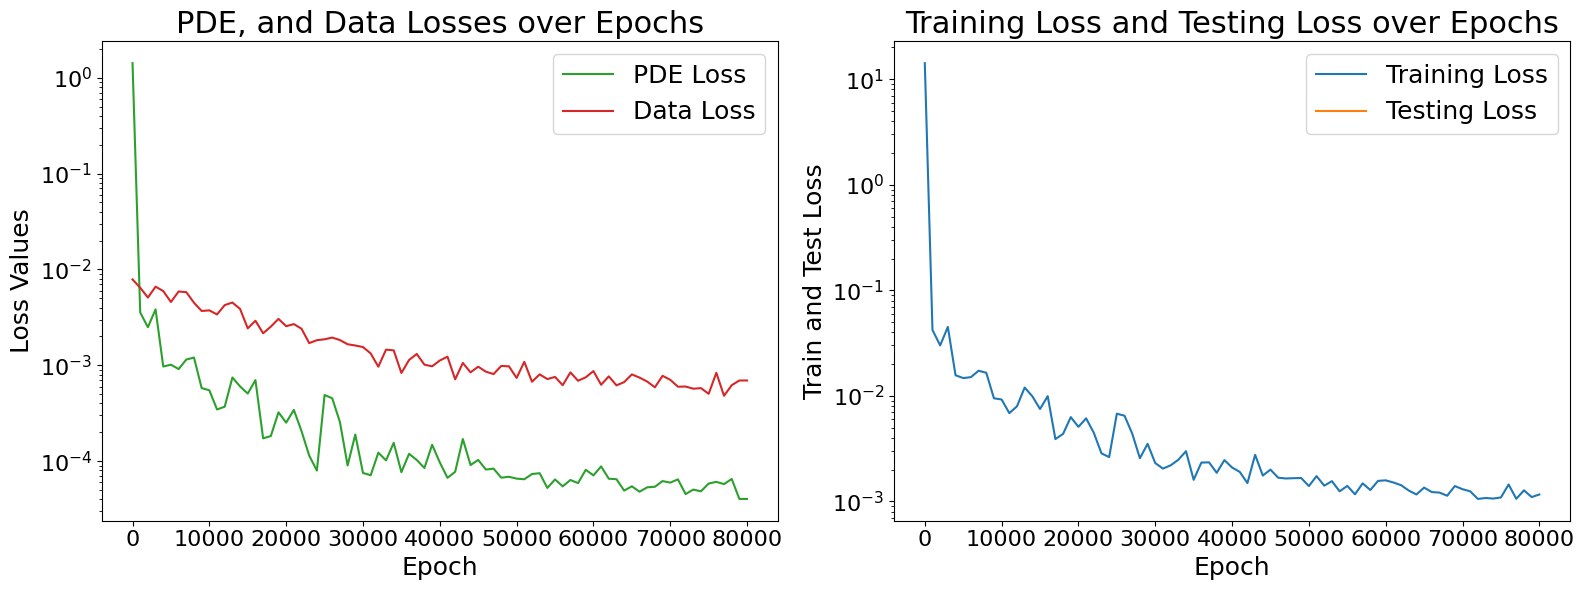

Plots saved to /scratch4/sgoswam4/Dibakar/INV_DON/RD/./results_inv_rd_D_d100_0/train_and_test_loss_plots.pdf


In [23]:
# Read the CSV file
csv_file = os.path.join(result_dir, "log.csv")  # Assuming the file is named "log.csv"
df = pd.read_csv(csv_file)

# Create the figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Set color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Left plot: epoch vs loss_ics_value, loss_bcs_value, and loss_res_value
ax1.plot(df['epoch'], df['loss_res_value'], label='PDE Loss', color=colors[2], linestyle='-')
ax1.plot(df['epoch'], df['loss_data_value'], label='Data Loss', color=colors[3], linestyle='-')
ax1.set_yscale("log")
ax1.set_xlabel('Epoch', fontsize=18)
ax1.set_ylabel('Loss Values', fontsize=18)
ax1.set_title('PDE, and Data Losses over Epochs', fontsize=22)
ax1.legend(loc='best', fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Right plot: epoch vs loss and l2err_val
ax2.plot(df['epoch'], df['loss'], label='Training Loss', color=colors[0], linestyle='-')
ax2.plot(df['epoch'], df['loss_test'], label='Testing Loss', color=colors[1], linestyle='-')
ax2.set_yscale("log")
ax2.set_xlabel('Epoch', fontsize=18)
ax2.set_ylabel('Train and Test Loss', fontsize=18)
ax2.set_title('Training Loss and Testing Loss over Epochs', fontsize=22)
ax2.legend(loc='best', fontsize=18)
ax2.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Adjust layout and save the figure
plt.tight_layout()
output_file = os.path.join(result_dir, "train_and_test_loss_plots.pdf")
plt.savefig(output_file, dpi=300)
plt.show()
plt.close()

print(f"Plots saved to {output_file}")

Loaded best model parameters
Visualizing test sample at index 0


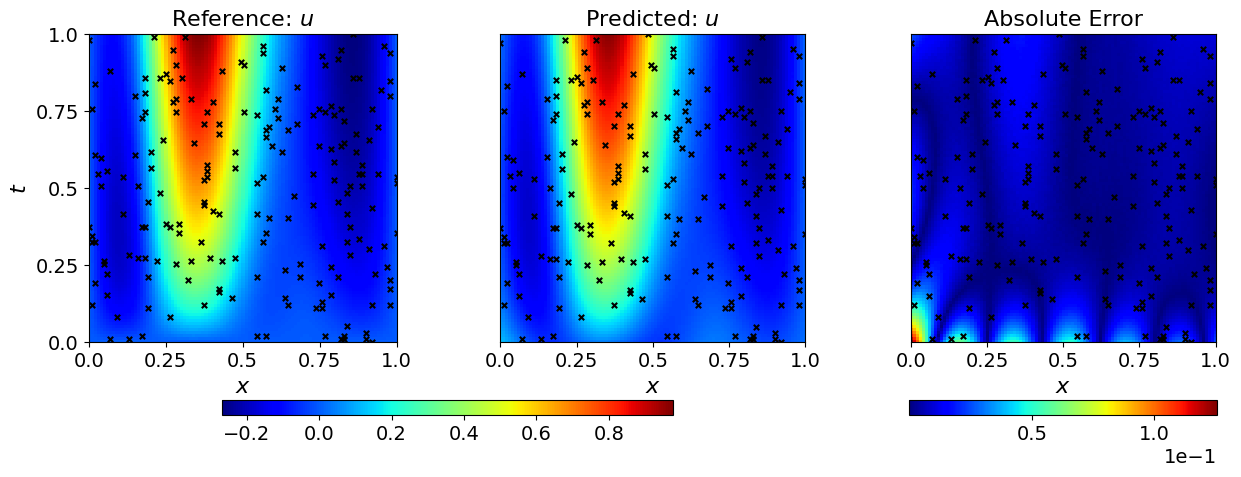

######################################################################################################################################################################################################################################
Visualizing test sample at index 500


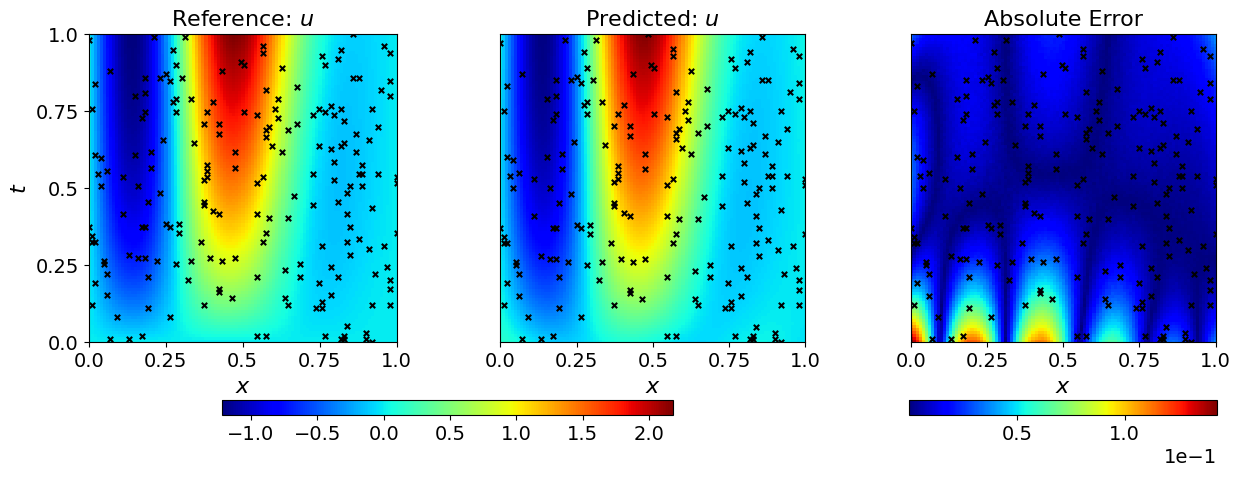

######################################################################################################################################################################################################################################
Visualizing test sample at index 1000


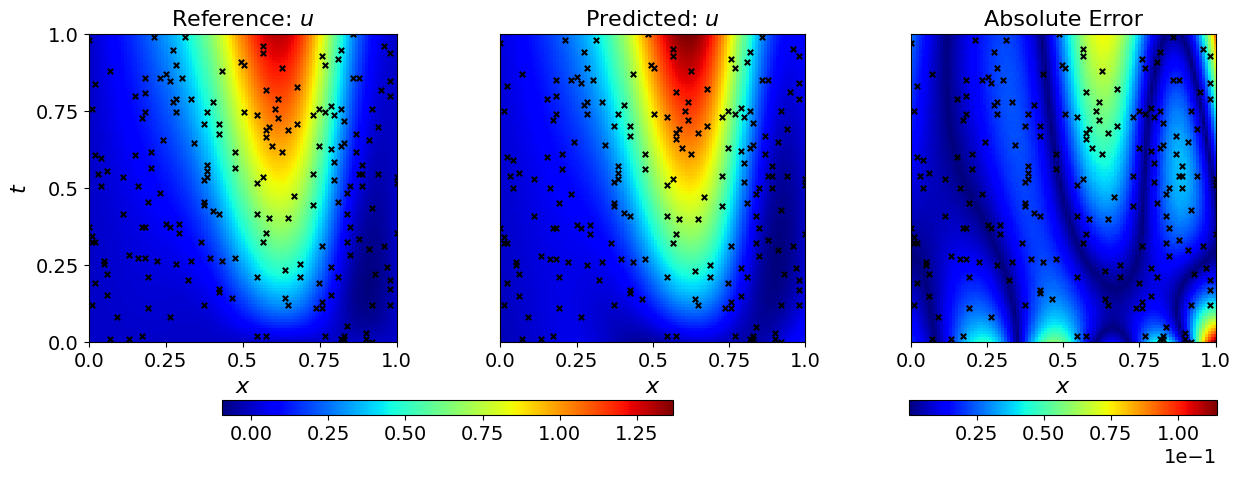

######################################################################################################################################################################################################################################
Visualizing test sample at index 1500


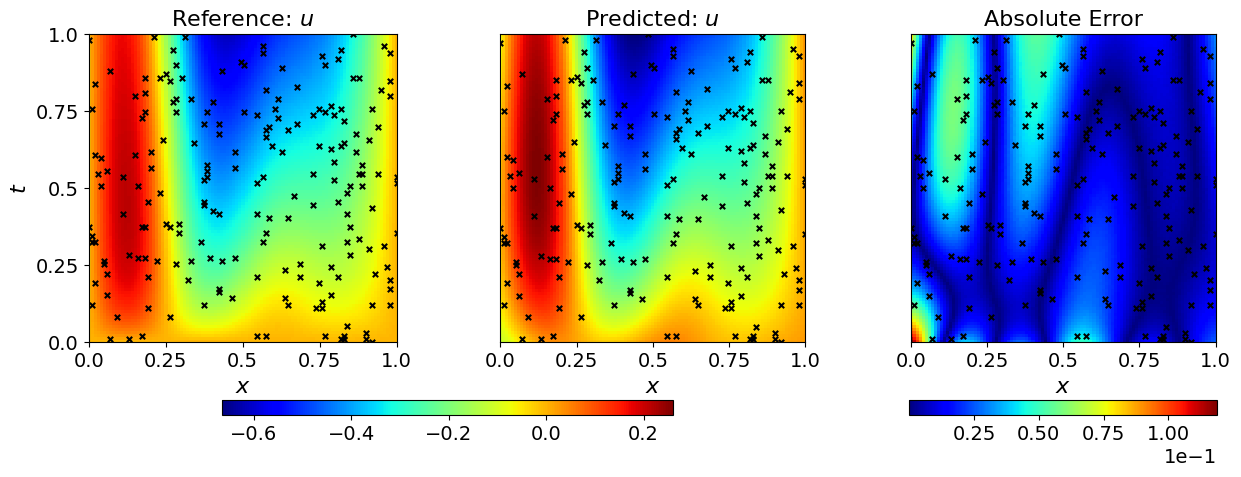

######################################################################################################################################################################################################################################
Visualizing test sample at index 2000


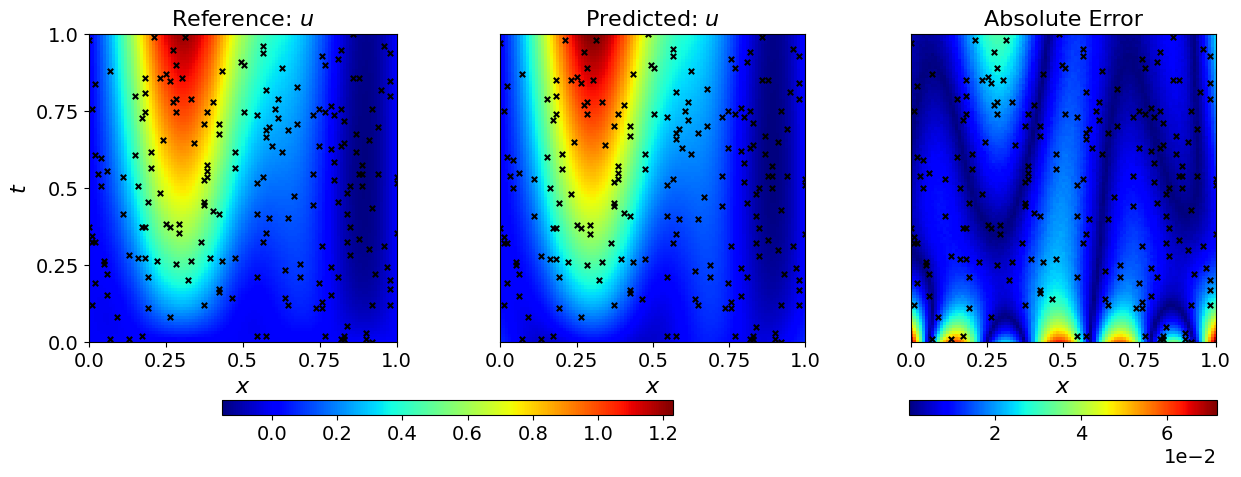

######################################################################################################################################################################################################################################
Visualizing test sample at index 2500


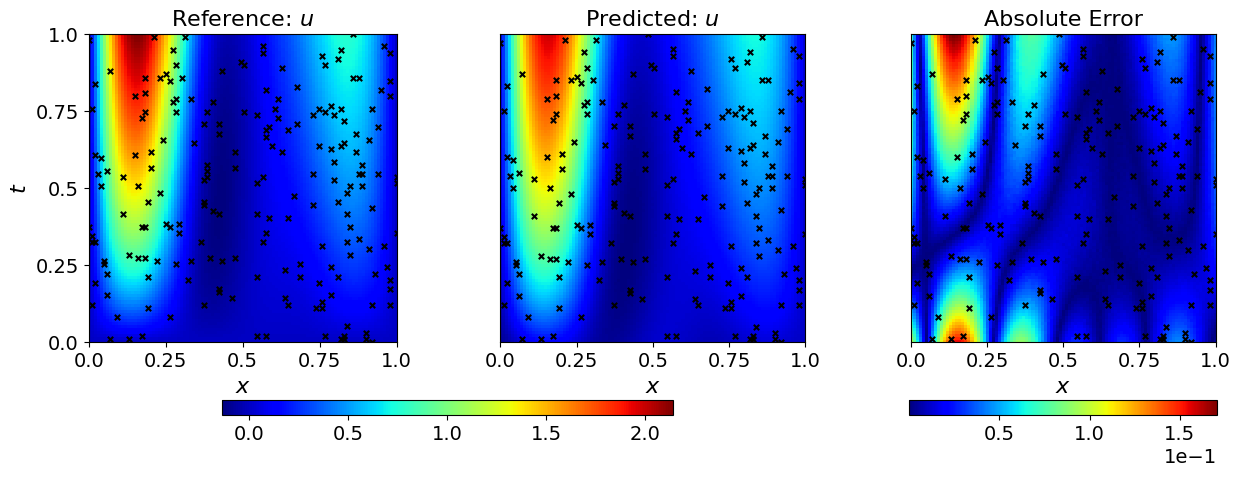

######################################################################################################################################################################################################################################
Visualizing test sample at index 3000


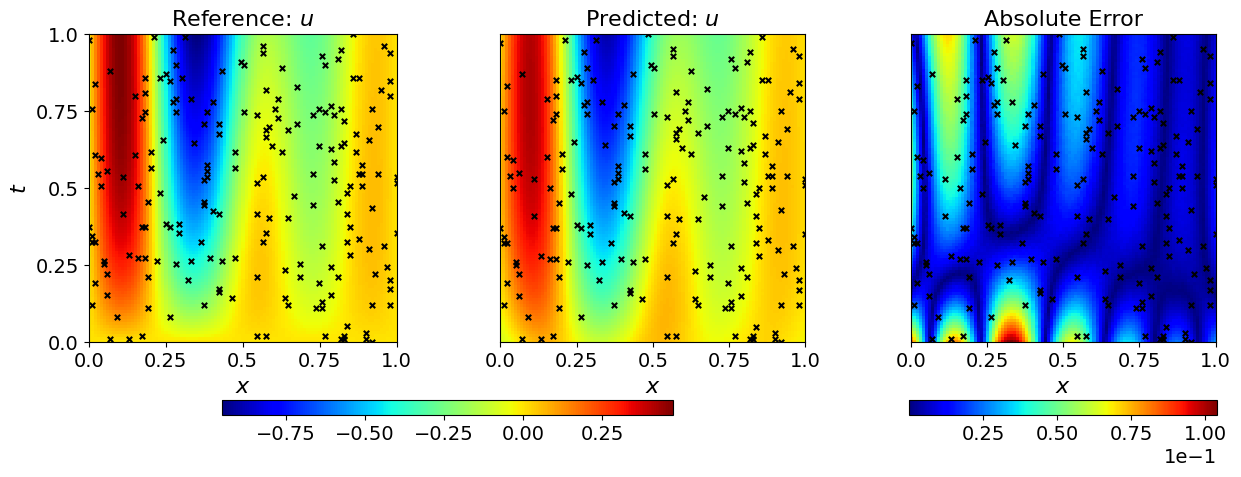

######################################################################################################################################################################################################################################
Visualizing test sample at index 3500


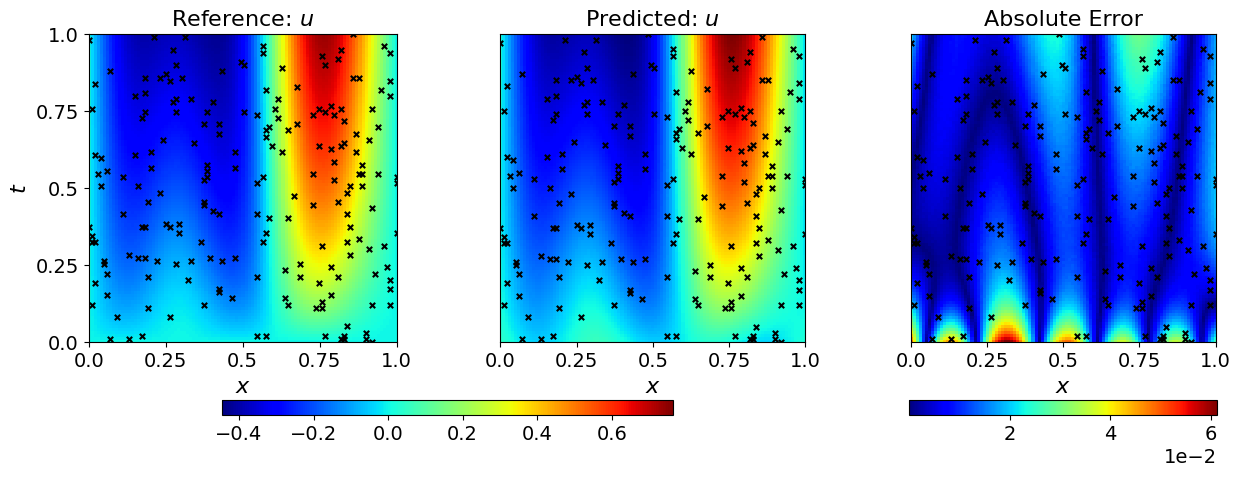

######################################################################################################################################################################################################################################
Mean MSE over test samples: 7.566e-04
Relative_L2 over test samples: 7.362e-02
abs_err_D:  (3600, 1)


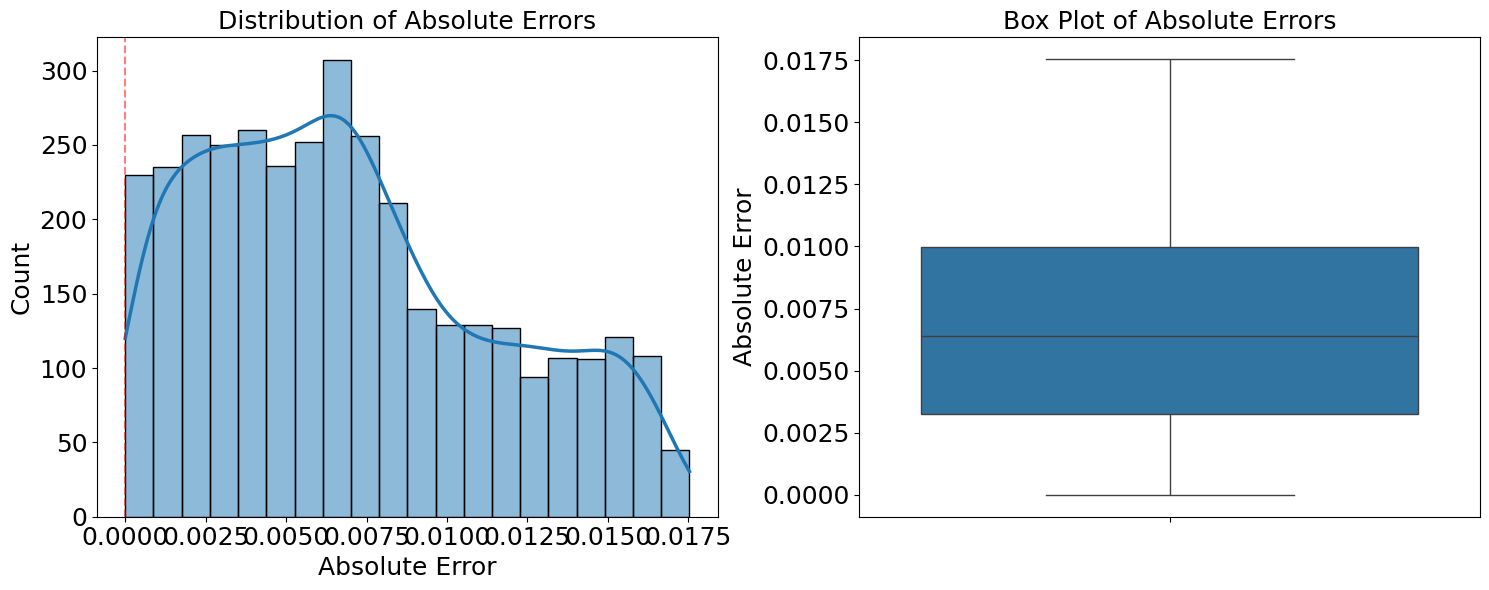


Error Distribution Statistics:
------------------------------
Mean Error: 0.007
Median Error: 0.006
Standard Deviation: 0.005
Minimum: 0.000
Maximum: 0.018

Outlier Analysis:
------------------------------
Number of outliers: 0
Percentage of outliers: 0.00%


In [24]:
"""# Test Visualization"""
import seaborn as sns

x = np.linspace(0.,1.,101)
t = np.linspace(0.,1.,101)

def get_axis_label(x,y,axis_interval):

    x_ = x.copy()
    y_ = y.copy()
    Nx_grid,Ny_grid = len(x_),len(y_)
    xpoints = list(np.arange(0,Nx_grid,Nx_grid//axis_interval))
    if Nx_grid-1 not in xpoints:
        xpoints.append(Nx_grid-1)
    ypoints = list(np.arange(0,Ny_grid,Ny_grid//axis_interval))
    if Ny_grid-1 not in ypoints:
        ypoints.append(Ny_grid-1)
    x_label_list = list(map( lambda x :round(x,2),[x_[val] for val in xpoints]))
    y_label_list = list(map( lambda x :round(x,2),[y_[val] for val in ypoints]))

    return xpoints, ypoints, x_label_list, y_label_list



xpoints, ypoints, x_label_list, y_label_list = get_axis_label(x,t,4)

"""# Test visualization"""

def loss_test_l2_error_one_sample(model_fn, params_loaded, data_output, u_sol_test, idx, location_test, return_data=False):

    t_test = jnp.linspace(0, 1, u_sol_test.shape[1])
    x_test = jnp.linspace(0, 1, u_sol_test.shape[2])

    xx_test, tt_test = jnp.meshgrid(x_test, t_test, indexing='ij')

    y = jnp.stack([tt_test.flatten(), xx_test.flatten()], axis=-1) #(100*100, 2)

    t = y[:,0]
    x = y[:,1]

    data_output_i = data_output[idx, :]
    data_output_i = data_output_i[jnp.newaxis,:]

    def ff_net(t, x):
        s_pred = apply_net(model_fn, params_loaded, data_output_i, t, x)
        return s_pred

    s_pred = ff_net(t, x)

    s_pred = s_pred.reshape(u_sol_test.shape[1], u_sol_test.shape[2])
    s_pred = s_pred.T

    loss_test = mse(u_sol_test[idx, :, :], s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(l2_norm_error(u_sol_test[idx,:,:], s_pred))

    # at known data (loactions)
    seed = 0
    key = jax.random.PRNGKey(seed)
    samples, ntt, nxx = u_sol_test.shape
    flattened_data = u_sol_test.reshape(samples, ntt * nxx)
    random_indices = jax.random.choice(key, ntt * nxx, shape=(200,), replace=False)
    t_indices = random_indices // ntt
    x_indices = random_indices % nxx

    s_pred_known_loc = s_pred[t_indices, x_indices]
    l2_error_data = jnp.mean(l2_norm_error(data_output[idx, :], s_pred_known_loc))

    if return_data:
        return loss_test, l2_error, s_pred, u_sol_test[idx,:,:], l2_error_data, s_pred_known_loc, data_output[idx, :]
    else:
        return loss_test, l2_error

def visualize_show(model_fn_nu, model_fn, params, result_dir, epoch, data_output, u_sol_test, nu_test, idx, location_test, test=False, save=False):
    params_loaded, params_nu = params
    loss_test, l2_error, s_pred, s_test, l2_error_data, s_pred_known_loc, s_known_data = loss_test_l2_error_one_sample(model_fn, params_loaded, data_output, u_sol_test, idx, location_test, return_data=True)

    nu_pred = apply_net_nu(model_fn_nu, params_nu, data_output)

    # Calculate R² score
    r2_value = metrics.r2_score(s_test.flatten(), s_pred.flatten())
    r2_value = float('%.4f' % r2_value)

    # Create figure with 1x3 subplot layout
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Find global min and max for consistent coloring
    arr_min = min(s_test.min(), s_pred.min())
    arr_max = max(s_test.max(), s_pred.max())

    # Plot 1: True field
    ax1 = axs[0]
    im1 = ax1.imshow(s_test, cmap='jet', origin='lower', vmin=arr_min, vmax=arr_max)
    ax1.scatter(location_test[:,1] * s_test.shape[1], location_test[:,0] * s_test.shape[0],
                marker='x', s=15, color='black')
    ax1.set_xlim(0,1)
    ax1.set_ylim(0,1)
    ax1.set_title('Reference: ' + r'$u$', fontsize=16)
    ax1.set_xticks(xpoints)
    ax1.set_xticklabels(x_label_list,fontsize=14)
    ax1.set_yticks(ypoints)
    ax1.set_yticklabels(y_label_list,fontsize=14)
    ax1.set_xlabel(r'$x$', fontsize=16)
    ax1.set_ylabel(r'$t$', fontsize=16)

    # Plot 2: Predicted field
    ax2 = axs[1]
    im2 = ax2.imshow(s_pred, cmap='jet', origin='lower', vmin=arr_min, vmax=arr_max)
    ax2.scatter(location_test[:,1] * s_pred.shape[1], location_test[:,0] * s_pred.shape[0],
                marker='x', s=15, color='black')
    ax2.set_xlim(0,1)
    ax2.set_ylim(0,101)
    ax2.set_title('Predicted: ' + r'$u$', fontsize=16)
    ax2.set_xticks(xpoints)
    ax2.set_xticklabels(x_label_list,fontsize=14)
    ax2.set_yticks([])
    ax2.set_xlabel(r'$x$', fontsize=16)

    # Plot 3: Field Absolute error
    ax3 = axs[2]
    u_diff = jnp.abs(s_test - s_pred)
    im3 = ax3.imshow(u_diff, cmap='jet', origin='lower')
    ax3.scatter(location_test[:,1] * u_diff.shape[1], location_test[:,0] * u_diff.shape[0],
                marker='x', s=15, color='black')
    ax3.set_xlim(0,1)
    ax3.set_ylim(0,101)
    ax3.set_title('Absolute Error', fontsize=16)
    ax3.set_xticks(xpoints)
    ax3.set_xticklabels(x_label_list,fontsize=14)
    ax3.set_yticks([])
    ax3.set_xlabel(r'$x$', fontsize=16)

    # Add colorbars
    cbar1 = fig.colorbar(im1, ax=[axs[0], axs[1]], location='bottom',
                        fraction=0.05, aspect=30, pad=0.15, shrink=0.6)
    cbar1.ax.tick_params(labelsize=14)

    cbar2 = fig.colorbar(im3, ax=axs[2], location='bottom',
                        fraction=0.05, aspect=20, pad=0.15, shrink=0.9)
    cbar2.formatter.set_powerlimits((0, 0))
    cbar2.formatter.set_useMathText(False)
    cbar2.ax.tick_params(labelsize=14)
    cbar2.ax.xaxis.get_offset_text().set(size=14)



    plt.savefig(os.path.join(result_dir, f'Test_Sample_{idx}.pdf'),
                    bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()
    print(colored('#' * 230, 'green'))

    return r2_value

# Initialize an empty list to store MSE values
mse_values = []

# Load the best model parameters
filename='model_params_best.pkl'
# filename='model_params.pkl'


load_path = os.path.join(result_dir, filename)
with open(load_path, 'rb') as f:
    best_params = pickle.load(f)

print("Loaded best model parameters")


# Loop over every 100th index to visualize and calculate R²
for i in range(target_test.shape[0]):
    if i % 500 == 0:
        idx = i
        print(f"Visualizing test sample at index {idx}")

        # Visualize and calculate R² score for every 100th index
        visualize_show(model_fn_nu, model_fn, best_params, result_dir, epochs, data_output, target_test, D_test, idx, location, True)

params_loaded, params_nu = best_params
# Calculate loss and l2 error for test samples
loss_test, l2_error = loss_test_l2_error(model_fn, params_loaded, data_output, target_test, return_data=False)

# Calculate and print the mean MSE over all test samples
# mean_mse = jnp.mean(jnp.array(mse_values))
print(f"Mean MSE over test samples: {loss_test:.3e}")
print(f"Relative_L2 over test samples: {l2_error:.3e}")



"""# Test nu prediction"""

D_pred = apply_net_nu(model_fn_nu, params_nu, data_output)

abs_err_nu = abs(D_test[0] - D_pred)

print("abs_err_D: ", str(abs_err_nu.shape))

def plot_error_distribution(rel_err_nu):
    """
    Create a side-by-side visualization of the error distribution

    Parameters:
    rel_err_nu: numpy array containing relative errors
    """
    # Create a figure with side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Histogram with KDE
    sns.histplot(rel_err_nu.flatten(), kde=True, line_kws=dict(linewidth=2.5),ax=ax1)
    ax1.set_title('Distribution of Absolute Errors', fontsize=18)
    ax1.set_xlabel('Absolute Error', fontsize=18)
    ax1.set_ylabel('Count', fontsize=18)
    ax1.axvline(x=0, color='r', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='both', which='major', labelsize=18)

    # Plot 2: Box plot
    sns.boxplot(y=rel_err_nu.flatten(), ax=ax2)
    ax2.set_title('Box Plot of Absolute Errors', fontsize=18)
    ax2.set_ylabel('Absolute Error', fontsize=18)
    ax2.tick_params(axis='both', which='major', labelsize=18)

    # Adjust layout and display
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f'abs_error_D.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()

    # Calculate and print statistics
    print("\nError Distribution Statistics:")
    print("-" * 30)
    print(f"Mean Error: {np.mean(rel_err_nu):.3f}")
    print(f"Median Error: {np.median(rel_err_nu):.3f}")
    print(f"Standard Deviation: {np.std(rel_err_nu):.3f}")
    print(f"Minimum: {np.min(rel_err_nu):.3f}")
    print(f"Maximum: {np.max(rel_err_nu):.3f}")

    # Calculate and print outlier information
    q1 = np.percentile(rel_err_nu, 25)
    q3 = np.percentile(rel_err_nu, 75)
    iqr = q3 - q1
    outliers = rel_err_nu[(rel_err_nu < (q1 - 1.5 * iqr)) | (rel_err_nu > (q3 + 1.5 * iqr))]
    print("\nOutlier Analysis:")
    print("-" * 30)
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {(len(outliers)/len(rel_err_nu)*100):.2f}%")

# Example usage:
plot_error_distribution(abs_err_nu)


In [25]:
print(f"Relative_L2 over test samples: {l2_error:.3e}")


Relative_L2 over test samples: 7.362e-02
